In [75]:
import os
import cv2
import numpy as np
import pandas as pd
from sklearn.utils import resample
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

In [76]:
# Define paths
photos_csv = "D:/yelp/yelpPhotos/yelp_photos/photos.csv"
photos_folder = "D:/yelp/yelpPhotos/yelp_photos/photos"

In [77]:
# Load and validate dataset
def load_dataset(csv_path, image_folder):
    if not os.path.exists(csv_path):
        raise FileNotFoundError(f"CSV file not found: {csv_path}")
    df = pd.read_csv(csv_path)
    if 'photo_id' not in df.columns or 'label' not in df.columns:
        raise KeyError("Missing required columns: 'photo_id' or 'label'")
    df['image_path'] = df['photo_id'].apply(lambda x: os.path.join(image_folder, f"{x}.jpg"))
    missing_images = [img for img in df['image_path'] if not os.path.exists(img)]
    if missing_images:
        print(f"Warning: {len(missing_images)} images are missing!")
    return df

In [78]:
# Load dataset
df = load_dataset(photos_csv, photos_folder)

In [79]:

# Balance dataset
def balance_dataset(df, sample_size=1000):
    categories = df['label'].value_counts().index.tolist()
    balanced_data = [
        resample(df[df['label'] == category], replace=True, n_samples=min(sample_size, df['label'].value_counts()[category]), random_state=42)
        for category in categories
    ]
    return pd.concat(balanced_data).sample(frac=1, random_state=42).reset_index(drop=True)

# Balance the dataset
df_balanced = balance_dataset(df)

In [80]:
# Image preprocessing with validation
def preprocess_image(image_path, target_size=(224, 224)):
    if not os.path.exists(image_path):
        print(f"Missing image: {image_path}")
        return None  # Skip processing for missing images
    print(f"Loading image: {image_path}")  # Print image path for debugging
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        print(f"Error loading image: {image_path}")
        return None  # Skip processing for invalid images
    img = cv2.GaussianBlur(img, (5, 5), 0)
    img = cv2.equalizeHist(img)
    _, img = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)
    img = cv2.resize(img, target_size)
    return np.expand_dims(img, axis=-1) / 255.0


In [81]:

# Filter and preprocess images
valid_image_paths = []  # List to store valid image paths
valid_labels = []       # List to store valid labels
X_images = []           # List to store preprocessed images

In [82]:
for img_path, label in zip(df_balanced['image_path'].values, df_balanced['label'].values):
    processed_image = preprocess_image(img_path)
    if processed_image is not None:  # Only add valid images and labels
        X_images.append(processed_image)
        valid_image_paths.append(img_path)
        valid_labels.append(label)

Loading image: D:/yelp/yelpPhotos/yelp_photos/photos\qUOMPx3K8sGpzxxyPf9ZtQ.jpg
Loading image: D:/yelp/yelpPhotos/yelp_photos/photos\AGF3Gh1X00vEJSCKo3N3EA.jpg
Loading image: D:/yelp/yelpPhotos/yelp_photos/photos\ozlrxNSdAWPWHB7g3E97Jg.jpg
Loading image: D:/yelp/yelpPhotos/yelp_photos/photos\BxQBh5kgNqm6b9R17hQBdA.jpg
Loading image: D:/yelp/yelpPhotos/yelp_photos/photos\1nsIM65bT2XMOr3NUvVV2g.jpg
Loading image: D:/yelp/yelpPhotos/yelp_photos/photos\A_Ot84VIrMimXnQzPvdq1Q.jpg
Loading image: D:/yelp/yelpPhotos/yelp_photos/photos\w8rX2hgdiYF0LSGLx5n6GQ.jpg
Loading image: D:/yelp/yelpPhotos/yelp_photos/photos\6aU6G99EkS3H83DEGYjPWw.jpg
Loading image: D:/yelp/yelpPhotos/yelp_photos/photos\VVBp_GJQNKBR76Ga7EcMmQ.jpg
Loading image: D:/yelp/yelpPhotos/yelp_photos/photos\5S0BtJLVmxdvAKt3MTaFUw.jpg
Loading image: D:/yelp/yelpPhotos/yelp_photos/photos\qE_F3nF0WV7QAbTYxhY4zQ.jpg
Loading image: D:/yelp/yelpPhotos/yelp_photos/photos\P1BDVVI498ujG8TbG9Ijcw.jpg
Loading image: D:/yelp/yelpPhotos/yelp_p

In [83]:
# Convert to numpy arrays
X_images = np.array(X_images)
y_labels = np.array(valid_labels)

# Ensure the lengths match
assert X_images.shape[0] == y_labels.shape[0], "Number of images and labels do not match!"

# Label encoding
label_encoder = LabelEncoder()
y_labels = label_encoder.fit_transform(y_labels)

In [84]:
# Split dataset into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X_images, y_labels, test_size=0.2, stratify=y_labels, random_state=42)

# Confirm the split
print(f"Training set size: {X_train.shape[0]}")
print(f"Validation set size: {X_val.shape[0]}")


Training set size: 3695
Validation set size: 924


In [85]:
import time
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Define the image data generator (for data augmentation)
train_datagen = ImageDataGenerator(
    rescale=1./255,  # Normalize pixel values to [0, 1]
    rotation_range=30,  # Random rotation
    width_shift_range=0.2,  # Random horizontal shift
    height_shift_range=0.2,  # Random vertical shift
    shear_range=0.2,  # Random shear transformation
    zoom_range=0.2,  # Random zoom
    horizontal_flip=True,  # Random horizontal flip
    fill_mode='nearest'  # Fill missing pixels during transformations
)


In [86]:
# Build model
def build_model():
    base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
    base_model.trainable = False  # Freeze the base model

    model = models.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dense(512, activation='relu'),
        layers.Dense(256, activation='relu'),
        layers.Dense(5, activation='softmax')  # Assuming 10 classes
    ])

    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001), 
                  loss='sparse_categorical_crossentropy', 
                  metrics=['accuracy'])
    
    return model

In [87]:
# Train model function
def train_model(model, X_train, y_train, X_val, y_val, epochs=10):
    early_stopping = callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
    lr_scheduler = callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)

    start_time = time.time()

    # Train the model using the augmented data
    history = model.fit(train_datagen.flow(X_train, y_train, batch_size=32), 
                        epochs=epochs, 
                        validation_data=(X_val, y_val),
                        callbacks=[early_stopping, lr_scheduler])

    print(f"Training completed in {time.time() - start_time:.2f} seconds")
    return history

In [88]:
# Build the model
model = build_model()

# Train the model
history = train_model(model, X_train, y_train, X_val, y_val)

E:\New folder\anaconda\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
116/116 ━━━━━━━━━━━━━━━━━━━━ 121s 836ms/step - accuracy: 0.2185 - loss: 1.6060 - val_accuracy: 0.2165 - val_loss: 1.5967 - learning_rate: 1.0000e-04
Epoch 2/10
116/116 ━━━━━━━━━━━━━━━━━━━━ 94s 808ms/step - accuracy: 0.1988 - loss: 1.6087 - val_accuracy: 0.2165 - val_loss: 1.5968 - learning_rate: 1.0000e-04
Epoch 3/10
116/116 ━━━━━━━━━━━━━━━━━━━━ 96s 824ms/step - accuracy: 0.2264 - loss: 1.5977 - val_accuracy: 0.2165 - val_loss: 1.5940 - learning_rate: 1.0000e-04
Epoch 4/10
116/116 ━━━━━━━━━━━━━━━━━━━━ 92s 790ms/step - accuracy: 0.1986 - loss: 1.6061 - val_accuracy: 0.1764 - val_loss: 1.5952 - learning_rate: 1.0000e-04
Epoch 5/10
116/116 ━━━━━━━━━━━━━━━━━━━━ 88s 760ms/step - accuracy: 0.2156 - loss: 1.5992 - val_accuracy: 0.2165 - val_loss: 1.5986 - learning_rate: 1.0000e-04
Epoch 6/10
116/116 ━━━━━━━━━━━━━━━━━━━━ 0s 600ms/step - accuracy: 0.2046 - loss: 1.6034
Epoch 6: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
116/116 ━━━━━━━━━━━━━━━━━━━━ 86s 741ms/s

In [89]:
# Fine-tune model
def fine_tune_model(model, X_train, y_train, X_val, y_val, epochs=5):
    # Define early stopping and learning rate scheduler within this function
    early_stopping = callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
    lr_scheduler = callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)

    # Set the base model layers to be trainable (fine-tuning)
    model.layers[0].trainable = True

    # Compile the model for fine-tuning
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5), 
                  loss='sparse_categorical_crossentropy', 
                  metrics=['accuracy'])
    
    start_time = time.time()

    # Train the model with fine-tuning
    history_finetune = model.fit(train_datagen.flow(X_train, y_train, batch_size=32), 
                                  epochs=epochs, 
                                  validation_data=(X_val, y_val),
                                  callbacks=[early_stopping, lr_scheduler])
    
    print(f"Fine-tuning completed in {time.time() - start_time:.2f} seconds")

# Run the fine-tuning
fine_tune_model(model, X_train, y_train, X_val, y_val)


Epoch 1/5
116/116 ━━━━━━━━━━━━━━━━━━━━ 1065s 3s/step - accuracy: 0.2039 - loss: 1.6257 - val_accuracy: 0.2273 - val_loss: 1.6036 - learning_rate: 1.0000e-05
Epoch 2/5
116/116 ━━━━━━━━━━━━━━━━━━━━ 367s 3s/step - accuracy: 0.3371 - loss: 1.5219 - val_accuracy: 0.1883 - val_loss: 1.6212 - learning_rate: 1.0000e-05
Epoch 3/5
116/116 ━━━━━━━━━━━━━━━━━━━━ 375s 3s/step - accuracy: 0.3887 - loss: 1.4450 - val_accuracy: 0.2229 - val_loss: 1.6747 - learning_rate: 1.0000e-05
Epoch 4/5
116/116 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.4464 - loss: 1.3637
Epoch 4: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-06.
116/116 ━━━━━━━━━━━━━━━━━━━━ 392s 3s/step - accuracy: 0.4465 - loss: 1.3635 - val_accuracy: 0.2121 - val_loss: 31.3481 - learning_rate: 1.0000e-05
Epoch 5/5
116/116 ━━━━━━━━━━━━━━━━━━━━ 384s 3s/step - accuracy: 0.4736 - loss: 1.2985 - val_accuracy: 0.2197 - val_loss: 1712.3820 - learning_rate: 5.0000e-06
Fine-tuning completed in 2584.64 seconds


  0%|          | 0/1000 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 372ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 337ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 351ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 367ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 332ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 521ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 323ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 331ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 396ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 381ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 456ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 433ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 329ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 406ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 594ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 358ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 520ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 470ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 553ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 528ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 452ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 468ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 343ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 399ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 

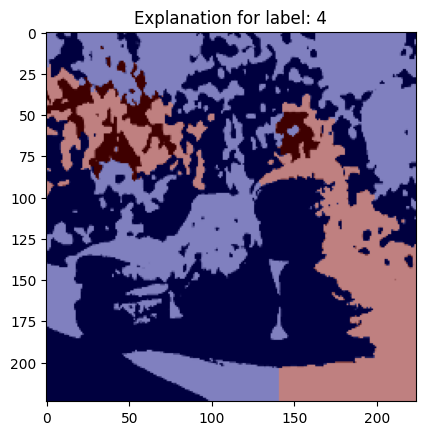

In [90]:
import numpy as np
import matplotlib.pyplot as plt
from lime import lime_image
from skimage import transform

def explain_prediction(model, X_val):
    explainer = lime_image.LimeImageExplainer()
    
    # Randomly select an image index
    idx = np.random.randint(0, len(X_val))
    
    # Ensure the image is in RGB format (if it has only one channel, repeat it to 3 channels)
    image = X_val[idx]
    if image.shape[-1] != 3:  # If not RGB, convert it to RGB by repeating the grayscale channel
        image = np.repeat(image, 3, axis=-1)
    
    # Use LIME to explain the prediction
    explanation = explainer.explain_instance(image, model.predict, top_labels=5, hide_color=0, num_samples=1000)
    
    # Get the explanation mask and image
    image, mask = explanation.get_image_and_mask(label=explanation.top_labels[0], 
                                                 positive_only=True, 
                                                 num_features=5, 
                                                 hide_rest=False)
    
    # Display the image with the explanation mask
    plt.imshow(image)
    plt.imshow(mask, cmap='jet', alpha=0.5)
    plt.title(f"Explanation for label: {explanation.top_labels[0]}")
    plt.show()

explain_prediction(model, X_val)


Unique classes in y_val (before encoding): [0 1 2 3 4]
29/29 - 18s - 632ms/step - accuracy: 0.2273 - loss: 1.6036
Test Accuracy: 0.2273
29/29 ━━━━━━━━━━━━━━━━━━━━ 20s 680ms/step
Shape of y_val: (924,)
Shape of y_pred: (924, 5)


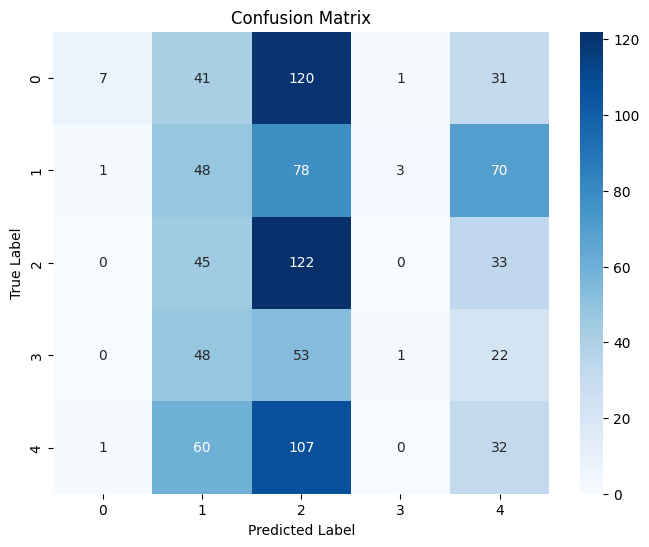

AUC (multi-class): 0.4954


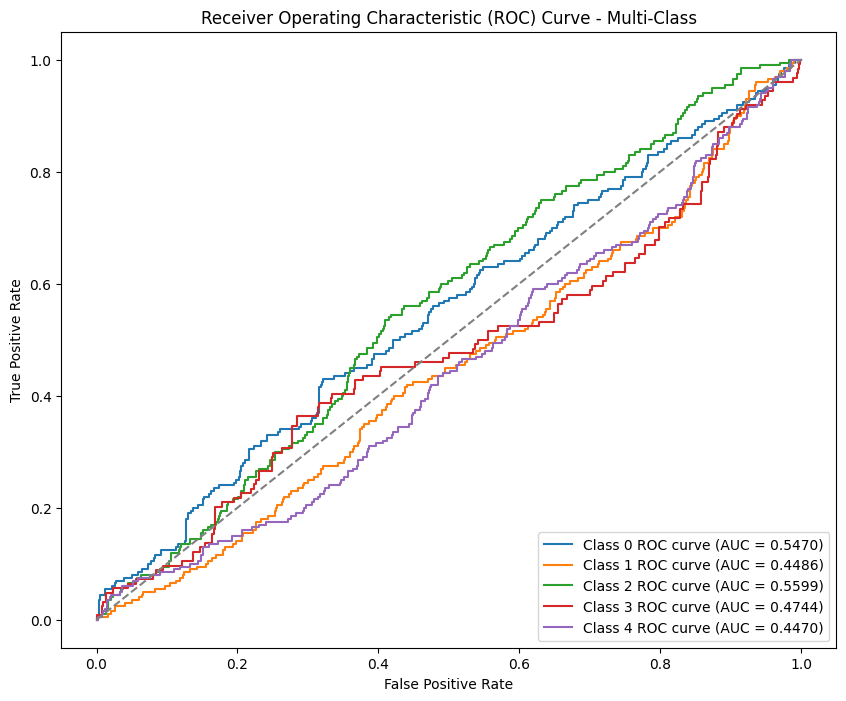

Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.04      0.07       200
           1       0.20      0.24      0.22       200
           2       0.25      0.61      0.36       200
           3       0.20      0.01      0.02       124
           4       0.17      0.16      0.16       200

    accuracy                           0.23       924
   macro avg       0.32      0.21      0.16       924
weighted avg       0.33      0.23      0.18       924



In [97]:
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import LabelBinarizer

def evaluate_model(model, X_val, y_val):
    """
    Evaluates a classification model using accuracy, confusion matrix, AUC, and classification report.
    Supports both binary and multi-class classification.
    """
    print("Unique classes in y_val (before encoding):", np.unique(y_val))
    
    # Evaluate the model
    test_loss, test_acc = model.evaluate(X_val, y_val, verbose=2)
    print(f"Test Accuracy: {test_acc:.4f}")
    
    # Predict probabilities
    y_pred = model.predict(X_val)
    print("Shape of y_val:", y_val.shape)
    print("Shape of y_pred:", y_pred.shape)
    
    # Get predicted class labels
    y_pred_classes = np.argmax(y_pred, axis=1)
    
    # Confusion matrix
    cm = confusion_matrix(y_val, y_pred_classes)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(y_val), yticklabels=np.unique(y_val))
    plt.title("Confusion Matrix")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.show()
    
    # Compute AUC
    num_classes = len(np.unique(y_val))
    
    # Multi-class AUC calculation and ROC curve plotting
    if num_classes > 2:
        lb = LabelBinarizer()
        y_val_bin = lb.fit_transform(y_val)  # One-hot encode true labels
        auc = roc_auc_score(y_val_bin, y_pred, multi_class='ovr', average='macro')
        print(f"AUC (multi-class): {auc:.4f}")

        # ROC Curve for multi-class classification
        plt.figure(figsize=(10, 8))
        for i in range(num_classes):
            fpr, tpr, _ = roc_curve(y_val_bin[:, i], y_pred[:, i])
            plt.plot(fpr, tpr, label=f"Class {i} ROC curve (AUC = {roc_auc_score(y_val_bin[:, i], y_pred[:, i]):.4f})")
        
        plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title("Receiver Operating Characteristic (ROC) Curve - Multi-Class")
        plt.legend(loc="lower right")
        plt.show()

    else:
        # Binary classification: AUC and ROC curve for positive class
        auc = roc_auc_score(y_val, y_pred[:, 1])
        fpr, tpr, _ = roc_curve(y_val, y_pred[:, 1])
        plt.figure(figsize=(8, 6))
        plt.plot(fpr, tpr, label=f"ROC curve (AUC = {auc:.4f})")
        plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title("Receiver Operating Characteristic (ROC) Curve")
        plt.legend(loc="lower right")
        plt.show()

    # Classification report
    print("Classification Report:")
    print(classification_report(y_val, y_pred_classes))

# Example usage
# model = ... # Load or define your model
# X_val = ... # Validation features
# y_val = ... # Validation labels
evaluate_model(model, X_val, y_val)  # Uncomment this line when running in an actual script
